In [1]:
import torch
import os

print(f"Setup complete. Using torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")

Setup complete. Using torch 2.2.1 (NVIDIA GeForce RTX 3060 Ti)


In [2]:
import torch
print(torch.__version__)

2.2.1


In [3]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [4]:
import warnings
warnings.filterwarnings(action='ignore') #이걸로 해야 실행

In [5]:
import numpy as np
import onnxruntime
import pprint
import cv2
from collections import defaultdict

# 이미지 전처리

In [6]:
def preprocess(input_image, input_width, input_height):
        """
        Preprocesses the input image before performing inference.

        Returns:
            image_data: Preprocessed image data ready for inference.
        """
        # Read the input image using OpenCV
        img = cv2.imread(input_image)

        # Convert the image color space from BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize the image to match the input shape
        img = cv2.resize(img, (input_width, input_height))

        # Normalize the image data by dividing it by 255.0
        image_data = np.array(img) / 255.0

        # Transpose the image to have the channel dimension as the first dimension
        image_data = np.transpose(image_data, (2, 0, 1))  # Channel first

        # Expand the dimensions of the image data to match the expected input shape
        image_data = np.expand_dims(image_data, axis=0).astype(np.float32)

        # Return the preprocessed image data
        return image_data

# 이미지 후처리

In [7]:
def postprocess(input_image, output, img_width, img_height, confidence_thres, iou_thres, color_palette, classes):
        """
        Performs post-processing on the model's output to extract bounding boxes, scores, and class IDs.

        Args:
            input_image (numpy.ndarray): The input image.
            output (numpy.ndarray): The output of the model.

        Returns:
            numpy.ndarray: The input image with detections drawn on it.
        """

        # Transpose and squeeze the output to match the expected shape
        outputs = np.transpose(np.squeeze(output[0]))

        # Get the number of rows in the outputs array
        rows = outputs.shape[0]

        # Lists to store the bounding boxes, scores, and class IDs of the detections
        boxes = []
        scores = []
        class_ids = []

        # Calculate the scaling factors for the bounding box coordinates
        x_factor = img_width / 640
        y_factor = img_height / 640

        # Iterate over each row in the outputs array
        for i in range(rows):
            # Extract the class scores from the current row
            classes_scores = outputs[i][4:]

            # Find the maximum score among the class scores
            max_score = np.amax(classes_scores)

            # If the maximum score is above the confidence threshold
            if max_score >= confidence_thres:
                # Get the class ID with the highest score
                class_id = np.argmax(classes_scores)

                # Extract the bounding box coordinates from the current row
                x, y, w, h = outputs[i][0], outputs[i][1], outputs[i][2], outputs[i][3]

                # Calculate the scaled coordinates of the bounding box
                left = int((x - w / 2) * x_factor)
                top = int((y - h / 2) * y_factor)
                width = int(w * x_factor)
                height = int(h * y_factor)

                # Add the class ID, score, and box coordinates to the respective lists
                class_ids.append(class_id)
                scores.append(max_score)
                boxes.append([left, top, width, height])

        # Apply non-maximum suppression to filter out overlapping bounding boxes
        indices = cv2.dnn.NMSBoxes(boxes, scores, confidence_thres, iou_thres)

        # Iterate over the selected indices after non-maximum suppression
        for i in indices:
            # Get the box, score, and class ID corresponding to the index
            box = boxes[i]
            score = scores[i]
            class_id = class_ids[i]

        
        # Return the modified input image
        return boxes, scores, class_ids

# 세팅

In [8]:
#로컬 yolov8
yolo = '/root/code/triton/model/yolo.onnx'
mrcnn = '/root/code/triton/model/mrcnn.onnx'
input_image = '/root/code/triton/img/case10.png'

confidence_thres = 0.7
iou_thres = 0.7

# Load the class names from the COCO dataset
classes = classes = {0: 'parking', 1: 'scooter', 2: 'wheel'}

# Generate a color palette for the classes
color_palette = np.random.uniform(0, 255, size=(len(classes), 3))

In [9]:
# Preprocess the image data
img_data =  preprocess(input_image, 640, 640)

# yolo

In [10]:
# Create an inference session using the ONNX model and specify execution providers
session_yolo = onnxruntime.InferenceSession(yolo, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

In [11]:
# Get the model inputs
model_inputs_yolo = session_yolo.get_inputs()

# Store the shape of the input for later use
input_shape = model_inputs_yolo[0].shape
input_width = input_shape[2]
input_height = input_shape[3]

In [12]:
# Run inference using the preprocessed image data
outputs_yolo = session_yolo.run(None, {model_inputs_yolo[0].name: img_data})

In [13]:
# Perform post-processing on the outputs to obtain output image.
boxes, scores, class_ids = postprocess(img_data, outputs_yolo, input_width, input_height, confidence_thres, iou_thres, color_palette, classes)  # output image

In [14]:
from collections import defaultdict

# 라벨별로 x, y, width, height 및 점수를 저장할 딕셔너리
label_coordinates = defaultdict(list)

for box, class_id, score in zip(boxes, class_ids, scores):
    x_min, y_min, width, height = box
    x_max, y_max = x_min + width, y_min + height
    # 'box'와 'score' 키를 사용하여 좌표와 점수를 저장
    label_coordinates[class_id].append({'box': [x_min, y_min, x_max, y_max], 'score': score})

#label_coordinates

In [15]:
# 각 클래스별로 점수가 가장 높은 박스를 찾기
highest_score_boxes = {}

for class_id, boxes in label_coordinates.items():
    # 점수를 기준으로 최대 값을 찾음
    highest_score_box = max(boxes, key=lambda x: x['score'])
    highest_score_boxes[class_id] = highest_score_box

#highest_score_boxes

# mrcnn

In [16]:
# Create an inference session using the ONNX model and specify execution providers
session_mrcnn = onnxruntime.InferenceSession(mrcnn, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

2024-03-14 17:08:03.378278682 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2016'. It is not used by any node and should be removed from the model.
2024-03-14 17:08:03.378352229 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2020'. It is not used by any node and should be removed from the model.
2024-03-14 17:08:03.378362688 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2592'. It is not used by any node and should be removed from the model.
2024-03-14 17:08:03.378365103 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2596'. It is not used by any node and should be removed from the model.
2024-03-14 17:08:03.378461943 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '3087'. It is not used by any node and should be removed from the model.
2024-03-14 17:08:03.378465109 [W:onnxruntime:

In [17]:
# Get the model inputs
model_inputs_mrcnn = session_mrcnn.get_inputs()

# Store the shape of the input for later use
input_shape = model_inputs_mrcnn[0].shape
input_width = input_shape[2]
input_height = input_shape[3]

In [18]:
# Run inference using the preprocessed image data
outputs_mrcnn = session_mrcnn.run(None, {model_inputs_mrcnn[0].name: img_data})

2024-03-14 17:08:04.574236159 [W:onnxruntime:, execution_frame.cc:858 VerifyOutputSizes] Expected shape from model of {1,640,640} does not match actual shape of {2,640,640} for output res_append.3
2024-03-14 17:08:04.575362750 [W:onnxruntime:, execution_frame.cc:858 VerifyOutputSizes] Expected shape from model of {1,640,640} does not match actual shape of {3,640,640} for output res_append.3


In [19]:
outputs_mrcnn

[array([[ 48.6208  , 325.10086 , 615.9333  , 514.5399  ],
        [ 67.866135, 217.14151 , 228.58826 , 606.569   ],
        [ 87.44266 , 396.74533 , 237.24991 , 592.2593  ]], dtype=float32),
 array([1, 2, 3], dtype=int64),
 array([0.9992229 , 0.9991652 , 0.99869317], dtype=float32),
 array([[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],
 
 
        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],
 
 
        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
   

In [20]:
# mrcnn 점수
mrcnn_labels = list(outputs_mrcnn[1])

mrcnn_p_idxs = [index for index, value in enumerate(mrcnn_labels) if value == 1]
mrcnn_sc_idxs = [index for index, value in enumerate(mrcnn_labels) if value == 2]
mrcnn_wh_idxs = [index for index, value in enumerate(mrcnn_labels) if value == 3]

parking_score = outputs_mrcnn[2][mrcnn_p_idxs]
scooter_score = outputs_mrcnn[2][mrcnn_sc_idxs]
wheel_score = outputs_mrcnn[2][mrcnn_wh_idxs]

mrcnn_scores=[parking_score, scooter_score,wheel_score] 

# IoU 추출

In [21]:
def get_overlapping_masks(yolo_box, mrcnn_result,labelID):
    #mrcnn_result indx 0: 좌표, 1: 인식한 라벨, 2: score, 3: mask
    idxs = [index for index, value in enumerate(mrcnn_result[1]) if value == labelID] #클래스 list

    for idx in idxs: 

        pos = mrcnn_result[0][idx] # 좌표
            
        x_min = pos[0]
        y_min = pos[1]
        x_max = pos[2]
        y_max = pos[3]
    
        # YOLO 바운딩 박스와 겹치는지 확인
        yolo_x1, yolo_y1, yolo_x2, yolo_y2 = yolo_box
        if x_min < yolo_x2 and x_max > yolo_x1 and y_min < yolo_y2 and y_max > yolo_y1:
            return mrcnn_result[3][idxs]>0.8
        else:
            pass
    
    return 0 #조건에 충족하는 좌표가 없음
    
def calculate_segmentation_iou(yolo_result, mrcnn_result):

    cls_idx = list(yolo_result.keys())

    # 'parking'과 'wheel' 클래스 ID
    parking_id = 0
    wheel_id = 2

    #두 객체 중 하나라도 없을 때
    try:
        parking_index = [index for index, value in enumerate(cls_idx) if value == parking_id]
        wheel_index = [index for index, value in enumerate(cls_idx) if value == wheel_id]
    except:
        return 0, 0, 0

    try:
        # YOLO 결과에서 'parking'과 'wheel' 바운딩 박스 좌표 추출
        parking_xyxy = yolo_result[parking_index[0]]['box']
        wheel_xyxy = yolo_result[wheel_index[0]]['box']

        # MRCNN 결과에서 겹치는 마스크 추출
        parking_masks = get_overlapping_masks(parking_xyxy, mrcnn_result, 1)
        wheel_masks = get_overlapping_masks(wheel_xyxy, mrcnn_result, 3)
    except:
        return 0, 0, 0
        
    # 교차 영역 및 합집합 영역 계산
    intersection = np.logical_and(parking_masks, wheel_masks)
    union = np.logical_or(parking_masks, wheel_masks)

    # IoU 계산
    iou = np.sum(intersection) / np.sum(wheel_masks) # 0~1
    
    
    
    return iou*100, intersection, union

In [22]:
iou, intersection, union = calculate_segmentation_iou(highest_score_boxes, outputs_mrcnn)

In [23]:
iou

67.07370737073708

# 결과 시각화

In [24]:
import torch
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms.v2  as transforms
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
import os

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [25]:
# 이미지를 불러오고, 텐서로 변환
image = Image.open(input_image)

In [26]:
# PIL 라이브러리를 사용하여 이미지를 불러옵니다.
background_image = Image.open(input_image)

# 이미지를 numpy 배열로 변환합니다.
background_image_np = np.array(background_image)

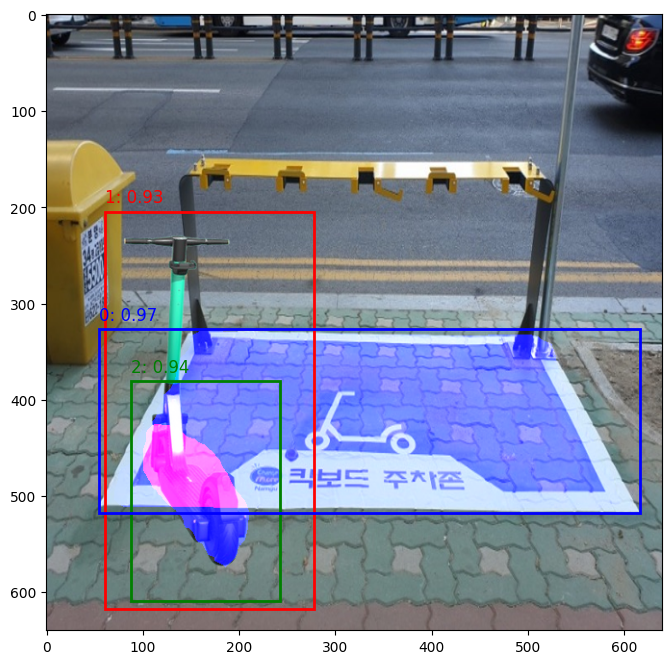

In [27]:
# 색상 정의
colors = ['red', 'green', 'blue'] 

# 마스크 데이터가 4차원 배열인지 확인하고, 필요한 부분만 추출합니다.
# Intersection 마스크
if intersection.ndim == 4:
    intersection_mask = intersection[0, 0, :, :]
else:
    intersection_mask = intersection.squeeze()  # 불필요한 차원 제거

# Union 마스크
if union.ndim == 4:
    union_mask = union[0, 0, :, :]
else:
    union_mask = union.squeeze()  # 불필요한 차원 제거

# 오버레이 이미지를 생성합니다. 배경 이미지와 동일한 형태의 배열을 생성합니다.
overlay = np.zeros_like(background_image_np, dtype=np.uint8)

#시각화 설정
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(background_image_np.astype(np.uint8))

# Intersection 마스크에 해당하는 부분을 빨간색으로 설정합니다.
overlay[intersection_mask, 0] = 255  # 빨간색 채널

# Union 마스크에 해당하는 부분을 파란색으로 설정합니다.
overlay[union_mask, 2] = 255  # 파란색 채널

# detections에서 각 객체의 경계 상자를 그림
for i, (det_id, det) in enumerate(highest_score_boxes.items()):
    box = det['box']
    rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                             linewidth=2, edgecolor=colors[i % len(colors)], facecolor='none')
    ax.add_patch(rect)
    # 상자 옆에 점수 표시
    plt.text(box[0], box[1] - 10, f'{det_id}: {det["score"]:.2f}', color=colors[i % len(colors)], fontsize=12)

combined_image = np.where(overlay, overlay, background_image_np).astype(np.uint8)

# 최종 이미지 시각화
plt.imshow(combined_image)
plt.show()

# 여러 이미지 실행

In [50]:
img_path = '/root/img/testing'
images = os.listdir(img_path)

In [ ]:
for image in images:
    input_image = img_path+'/'+image
        
    confidence_thres = 0.7
    iou_thres = 0.7
        
    # Load the class names from the COCO dataset
    classes = classes = {0: 'parking', 1: 'scooter', 2: 'wheel'}
        
    # Generate a color palette for the classes
    color_palette = np.random.uniform(0, 255, size=(len(classes), 3))
    
    # Preprocess the image data
    img_data =  preprocess(input_image, 640, 640)
    
    # Get the model inputs
    model_inputs_yolo = session_yolo.get_inputs()
    
    # Store the shape of the input for later use
    input_shape = model_inputs_yolo[0].shape
    input_width = input_shape[2]
    input_height = input_shape[3]
    
    # Run inference using the preprocessed image data
    outputs_yolo = session_yolo.run(None, {model_inputs_yolo[0].name: img_data})
    
    # Perform post-processing on the outputs to obtain output image.
    boxes, scores, class_ids = postprocess(img_data, outputs_yolo, input_width, input_height, confidence_thres, iou_thres, color_palette, classes)  # output image
    
    # 라벨별로 x_min, y_min, x_max, y_max 및 점수를 저장할 딕셔너리
    label_coordinates = defaultdict(list)
    
    for box, class_id, score in zip(boxes, class_ids, scores):
        x_min, y_min, width, height = box
        x_max, y_max = x_min + width, y_min + height
        # 'box'와 'score' 키를 사용하여 좌표와 점수를 저장
        label_coordinates[class_id].append({'box': [x_min, y_min, x_max, y_max], 'score': score})
    
    
    # 각 클래스별로 점수가 가장 높은 박스를 찾기
    highest_score_boxes = {}
    
    for class_id, boxes in label_coordinates.items():
        # 점수를 기준으로 최대 값을 찾음
        highest_score_box = max(boxes, key=lambda x: x['score'])
        highest_score_boxes[class_id] = highest_score_box
    
    
    # Get the model inputs
    model_inputs_mrcnn = session_mrcnn.get_inputs()
    
    # Store the shape of the input for later use
    input_shape = model_inputs_mrcnn[0].shape
    input_width = input_shape[2]
    input_height = input_shape[3]
    
    # Run inference using the preprocessed image data
    outputs_mrcnn = session_mrcnn.run(None, {model_inputs_mrcnn[0].name: img_data})
    
    iou, intersection, union = calculate_segmentation_iou(highest_score_boxes, outputs_mrcnn)

    ####
    
    # PIL 라이브러리를 사용하여 이미지를 불러옵니다.
    background_image = Image.open(input_image)
    
    
    # 이미지를 640x640 크기로 리사이징합니다.
    background_image = background_image.resize((640, 640), Image.BILINEAR)
    
    # 이미지를 numpy 배열로 변환합니다.
    background_image_np = np.array(background_image)
    
    # 색상 정의
    colors = ['red', 'green', 'blue'] 
    
    # 마스크 데이터가 4차원 배열인지 확인하고, 필요한 부분만 추출합니다.
    # Intersection 마스크
    if intersection.ndim == 4:
        intersection_mask = intersection[0, 0, :, :]
    else:
        intersection_mask = intersection.squeeze()  # 불필요한 차원 제거
    
    # Union 마스크
    if union.ndim == 4:
        union_mask = union[0, 0, :, :]
    else:
        union_mask = union.squeeze()  # 불필요한 차원 제거
    
    # 오버레이 이미지를 생성합니다. 배경 이미지와 동일한 형태의 배열을 생성합니다.
    overlay = np.zeros_like(background_image_np, dtype=np.uint8)
    
    #시각화 설정
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(background_image_np.astype(np.uint8))
    
    # Intersection 마스크에 해당하는 부분을 빨간색으로 설정합니다.
    overlay[intersection_mask, 0] = 255  # 빨간색 채널
    
    # Union 마스크에 해당하는 부분을 파란색으로 설정합니다.
    overlay[union_mask, 2] = 255  # 파란색 채널
    
    # detections에서 각 객체의 경계 상자를 그림
    for i, (det_id, det) in enumerate(highest_score_boxes.items()):
        box = det['box']
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                 linewidth=2, edgecolor=colors[i % len(colors)], facecolor='none')
        ax.add_patch(rect)
        # 상자 옆에 점수 표시
        plt.text(box[0], box[1] - 10, f'{det_id}: {det["score"]:.2f}', color=colors[i % len(colors)], fontsize=12)

    #IoU 값을 출력하기 위해 플롯에 텍스트 추가
    iou_text = f'IoU: {iou:.2f}'
    plt.text(10, 25, iou_text, color='yellow', fontsize=15, bbox=dict(facecolor='black', alpha=0.5))

    combined_image = np.where(overlay, overlay, background_image_np).astype(np.uint8)
    
    # 최종 이미지 시각화
    plt.imshow(combined_image)
    plt.title(image)

    # 이미지를 저장할 경로 설정
    save_path = '/root/img/visual'  # 이 부분을 원하는 저장 경로로 변경하세요
    save_filename = os.path.join(save_path, f'processed_{image}')
    
    # 이미지 저장
    save_filename = os.path.join(save_path, f'processed_{image}')
    plt.savefig(save_filename, bbox_inches='tight')
    
    plt.show()  # YOLO 모델 세션

# triton client

In [52]:
import requests
import json
from PIL import Image
import io
import numpy as np
from PIL import Image
import tritonclient.grpc as grpcclient
from tritonclient.utils import InferenceServerException
import os

# Triton 서버 주소: 환경 변수 TRITON_HOST로 넣는다 (공개 저장소에서는 실제 주소를 뺐다).
TRITON_HOST = os.environ.get('TRITON_HOST', 'localhost')

In [53]:
IMAGE_PATH = '/root/code/triton/img/case10.png'

In [ ]:
%%time

from PIL import Image
import numpy as np
import tritonclient.grpc as grpcclient
from tritonclient.utils import InferenceServerException

try:
    image = Image.open(IMAGE_PATH).convert('RGB')
    image_np = np.array(image).astype(np.float32)

    triton_client = grpcclient.InferenceServerClient(url=f'{TRITON_HOST}:8001', verbose=False)

    # InferInput 객체 생성
    input0 = grpcclient.InferInput('ensemble_input', image_np.shape, "FP32")

    # ndarray 데이터를 InferInput에 설정
    input0.set_data_from_numpy(image_np)

    # 결과를 받을 출력 정의
    output_point = grpcclient.InferRequestedOutput('output_point')
    output_scores = grpcclient.InferRequestedOutput('output_scores')

    # 추론 실행
    results = triton_client.infer(model_name='ensemble',
                                  inputs=[input0],
                                  outputs=[output_point, output_scores])

    # 결과에서 numpy 배열 추출
    output_data1 = results.as_numpy('output_point')
    print(f'point: {output_data1[0]}')
    output_data2 = results.as_numpy('output_scores')
    print(f'scores: {output_data2}')

except InferenceServerException as e:
    print("InferenceServerException: {}".format(e))


# triton before vs after

In [55]:
import numpy as np
import onnxruntime
import pprint
import cv2
from collections import defaultdict

In [56]:
IMAGE_PATH = '/root/code/triton/img/case10.png'

## triton server

In [57]:
def triton_run(IMAGE_PATH):
    try:
        image = Image.open(IMAGE_PATH).convert('RGB')
        image_resized = image.resize((640, 640))
        image_np = np.array(image_resized).astype(np.float32)
    
        triton_client = grpcclient.InferenceServerClient(url=f'{TRITON_HOST}:8001', verbose=False)
    
        # InferInput 객체 생성
        input0 = grpcclient.InferInput('ensemble_input', image_np.shape, "FP32")
    
        # ndarray 데이터를 InferInput에 설정
        input0.set_data_from_numpy(image_np)
    
        # 결과를 받을 출력 정의
        output_point = grpcclient.InferRequestedOutput('output_point')
        output_scores = grpcclient.InferRequestedOutput('output_scores')
    
        # 추론 실행
        results = triton_client.infer(model_name='ensemble',
                                      inputs=[input0],
                                      outputs=[output_point, output_scores])
    
        # 결과에서 numpy 배열 추출
        output_data1 = results.as_numpy('output_point')
        output_data2 = results.as_numpy('output_scores')
        return output_data2
    
    except InferenceServerException as e:
        print("InferenceServerException: {}".format(e))



In [61]:
def yolo_mrcnn(IMAGE_PATH):
    confidence_thres = 0.7
    iou_thres = 0.7
        
    # Load the class names from the COCO dataset
    classes = classes = {0: 'parking', 1: 'scooter', 2: 'wheel'}
        
    # Generate a color palette for the classes
    color_palette = np.random.uniform(0, 255, size=(len(classes), 3))
    
    # Preprocess the image data
    img_data =  preprocess(IMAGE_PATH, 640, 640)

    ### yolo.onnx
    yolo = '/root/code/triton/model/yolo.onnx'
    # Create an inference session using the ONNX model and specify execution providers
    session_yolo = onnxruntime.InferenceSession(yolo, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    
    # Get the model inputs
    model_inputs_yolo = session_yolo.get_inputs()
    
    # Store the shape of the input for later use
    input_shape = model_inputs_yolo[0].shape
    input_width = input_shape[2]
    input_height = input_shape[3]
    
    # Run inference using the preprocessed image data
    outputs_yolo = session_yolo.run(None, {model_inputs_yolo[0].name: img_data})
    
    # Perform post-processing on the outputs to obtain output image.
    boxes, scores, class_ids = postprocess(img_data, outputs_yolo, input_width, input_height, confidence_thres, iou_thres, color_palette, classes)  # output image
    
    # 라벨별로 x_min, y_min, x_max, y_max 및 점수를 저장할 딕셔너리
    label_coordinates = defaultdict(list)
    
    for box, class_id, score in zip(boxes, class_ids, scores):
        x_min, y_min, width, height = box
        x_max, y_max = x_min + width, y_min + height
        # 'box'와 'score' 키를 사용하여 좌표와 점수를 저장
        label_coordinates[class_id].append({'box': [x_min, y_min, x_max, y_max], 'score': score})
    
    
    # 각 클래스별로 점수가 가장 높은 박스를 찾기
    highest_score_boxes = {}
    
    for class_id, boxes in label_coordinates.items():
        # 점수를 기준으로 최대 값을 찾음
        highest_score_box = max(boxes, key=lambda x: x['score'])
        highest_score_boxes[class_id] = highest_score_box
        
    cls_idx = list(highest_score_boxes.keys())

    # 'parking'과 'wheel' 클래스 ID
    parking_id = 0
    sctooer = 1
    wheel_id = 2

    #두 객체 중 하나라도 없을 때
    try:
        parking_index = [index for index, value in enumerate(cls_idx) if value == parking_id]
        scooter_index = [index for index, value in enumerate(cls_idx) if value == sctooer]
        wheel_index = [index for index, value in enumerate(cls_idx) if value == wheel_id]
    except:
        return 0

    yolo_scores=[highest_score_boxes[parking_index[0]]['score'], highest_score_boxes[scooter_index[0]]['score'], highest_score_boxes[wheel_index[0]]['score']]

    ## mrcnn.onnx
    mrcnn = '/root/code/triton/model/mrcnn.onnx'

    # Create an inference session using the ONNX model and specify execution providers
    session_mrcnn = onnxruntime.InferenceSession(mrcnn, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    
    # Get the model inputs
    model_inputs_mrcnn = session_mrcnn.get_inputs()
    
    # Store the shape of the input for later use
    input_shape = model_inputs_mrcnn[0].shape
    input_width = input_shape[2]
    input_height = input_shape[3]
    
    # Run inference using the preprocessed image data
    outputs_mrcnn = session_mrcnn.run(None, {model_inputs_mrcnn[0].name: img_data})
    
    # in vs out
    iou, intersection, union = calculate_segmentation_iou(highest_score_boxes, outputs_mrcnn)

    # mrcnn 점수
    mrcnn_labels = list(outputs_mrcnn[1])
    
    mrcnn_p_idxs = [index for index, value in enumerate(mrcnn_labels) if value == 1]
    mrcnn_sc_idxs = [index for index, value in enumerate(mrcnn_labels) if value == 2]
    mrcnn_wh_idxs = [index for index, value in enumerate(mrcnn_labels) if value == 3]
    
    parking_score = outputs_mrcnn[2][mrcnn_p_idxs][0]
    scooter_score = outputs_mrcnn[2][mrcnn_sc_idxs][0]
    wheel_score = outputs_mrcnn[2][mrcnn_wh_idxs][0]
    
    mrcnn_scores=[parking_score, scooter_score,wheel_score] 
    
    scores=[]
    
    scores.append(yolo_scores)
    scores.append(mrcnn_scores)
    
    # stand vs fall
    pos = highest_score_boxes[1]['box']
    width = pos[2]
    height = pos[3]

    

    cont1 = 91<=iou<=100
    cont2 = 70<=iou<90
    cont3 = 41<=iou<=69
    cont4 = 11<=iou<=40

    cls_yolo = list(highest_score_boxes.keys())

    
    point = 0
    if 0 in cls_yolo: #주차장 유무
        if width < height: #stand
            if cont1:
                point = 20
            elif cont2:
                point = 16
            elif cont3:
                point = 12
            elif cont4:
                point = 8
            else:
                point = 4
        else: #fall
            if cont1:
                point = 18
            elif cont2:
                point = 14
            elif cont3:
                point = 10
            elif cont4:
                point = 6
            else:
                point = 2
    else:
        if width < height: #stand
            potin = 4
        else:
            point = 2
    # print(f'point: {point}')
    return scores
    

In [ ]:
%%time
triton_scores = triton_run(IMAGE_PATH)
triton_scores

In [62]:
%%time
a_scores = yolo_mrcnn(IMAGE_PATH)
a_scores

2024-03-14 17:43:58.424200117 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2016'. It is not used by any node and should be removed from the model.
2024-03-14 17:43:58.424233879 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2020'. It is not used by any node and should be removed from the model.
2024-03-14 17:43:58.424241383 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2592'. It is not used by any node and should be removed from the model.
2024-03-14 17:43:58.424243487 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '2596'. It is not used by any node and should be removed from the model.
2024-03-14 17:43:58.424339957 [W:onnxruntime:, graph.cc:3593 CleanUnusedInitializersAndNodeArgs] Removing initializer '3087'. It is not used by any node and should be removed from the model.
2024-03-14 17:43:58.424343183 [W:onnxruntime:

CPU times: user 19.5 s, sys: 1.11 s, total: 20.6 s
Wall time: 1.98 s


2024-03-14 17:43:59.496153495 [W:onnxruntime:, execution_frame.cc:858 VerifyOutputSizes] Expected shape from model of {1,640,640} does not match actual shape of {2,640,640} for output res_append.3
2024-03-14 17:43:59.497111201 [W:onnxruntime:, execution_frame.cc:858 VerifyOutputSizes] Expected shape from model of {1,640,640} does not match actual shape of {3,640,640} for output res_append.3


[[0.9421531, 0.9650979, 0.9295207], [0.9992229, 0.9991652, 0.99869317]]

## 실행시간 시각화

In [ ]:
import time
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm

img_path = '/root/img/images'

# img_path 디렉터리 내의 파일 목록을 가져옵니다.
file_lis = os.listdir(img_path)

# PNG 파일만 선택하여 랜덤 이미지 경로 리스트 생성
random_images = [os.path.join(img_path, file) for file in file_lis if file.endswith('.png')][:30]

# 각 함수의 실행 시간을 저장할 리스트
yolo_mrcnn_times = []
triton_run_times = []

# 50개의 랜덤 이미지에 대해 함수 실행 시간 측정
for image in tqdm(random_images):
    start = time.time()
    yolo_mrcnn(image)
    yolo_mrcnn_times.append(time.time() - start)

    start = time.time()
    triton_run(image)
    triton_run_times.append(time.time() - start)

# 평균 시간 계산
average_yolo_mrcnn = sum(yolo_mrcnn_times) / len(yolo_mrcnn_times)
average_triton_run = sum(triton_run_times) / len(triton_run_times)

# 그래프로 시각화
plt.plot(yolo_mrcnn_times, label='YOLO MRCNN')
plt.plot(triton_run_times, label='Triton Run')
plt.xlabel('Image Number')
plt.ylabel('Time (seconds)')
plt.title('Execution Time Comparison')
plt.legend()
plt.show()

average_yolo_mrcnn, average_triton_run

In [ ]:
import time
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm

img_path = '/root/img/images'
file_list = os.listdir(img_path)

# PNG 파일만 선택
png_files = [file for file in file_list if file.endswith('.png')]

# 각 함수의 실행 시간을 저장할 리스트
yolo_mrcnn_times = []
triton_run_times = []

# 100회 실행을 위한 루프
i = 0
while len(yolo_mrcnn_times) < 100 and len(triton_run_times) < 100 and i < len(png_files):
    image_path = os.path.join(img_path, png_files[i])
    i += 1

    try:
        start = time.time()
        yolo_mrcnn(image_path)
        yolo_mrcnn_times.append(time.time() - start)
    except Exception as e:
        print(f"Error processing with yolo_mrcnn: {e}")

    try:
        start = time.time()
        triton_run(image_path)
        triton_run_times.append(time.time() - start)
    except Exception as e:
        print(f"Error processing with triton_run: {e}")

# 평균 시간 계산
average_yolo_mrcnn = sum(yolo_mrcnn_times) / len(yolo_mrcnn_times)
average_triton_run = sum(triton_run_times) / len(triton_run_times)

# 그래프로 시각화
plt.plot(yolo_mrcnn_times, label='YOLO MRCNN')
plt.plot(triton_run_times, label='Triton Run')
plt.xlabel('Image Number')
plt.ylabel('Time (seconds)')
plt.title('Execution Time Comparison')
plt.legend()
plt.show()

print(average_yolo_mrcnn, average_triton_run)

In [ ]:
# 그래프를 파일로 저장
plt.savefig('graph.png')

In [ ]:
plt.show()

## 객체 탐지 평균 scoure

In [ ]:
# 데이터를 NumPy 배열로 변환
triton_yolo_scores = np.array(triton_yolo_scores)
triton_mrcnn_scores = np.array(triton_mrcnn_scores)
a_yolo_scores = np.array(a_yolo_scores)
a_mrcnn_scores = np.array(a_mrcnn_scores)

# 모델별 점수 평균 계산
triton_yolo_avg = np.mean(triton_yolo_scores, axis=0)
triton_mrcnn_avg = np.mean(triton_mrcnn_scores, axis=0)
a_yolo_avg = np.mean(a_yolo_scores, axis=0)
a_mrcnn_avg = np.mean(a_mrcnn_scores, axis=0)

# 시각화
# 라벨 및 기타 설정
labels = ['Parking', 'Scooter', 'Wheel']
x = np.arange(len(labels))
width = 0.35

# 그래프 생성
fig, axs = plt.subplots(2, 1, figsize=(5,5))

# YOLO 그래프
axs[0].bar(x - width/2, triton_yolo_avg, width, label='Triton YOLO')
axs[0].bar(x + width/2, a_yolo_avg, width, label='YOLO')
axs[0].set_ylabel('Scores')
axs[0].set_title('Average Scores by Model and Class (YOLO)')
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels)
axs[0].legend()

# MRCNN 그래프
axs[1].bar(x - width/2, triton_mrcnn_avg, width, label='Triton MRCNN')
axs[1].bar(x + width/2, a_mrcnn_avg, width, label='MRCNN')
axs[1].set_ylabel('Scores')
axs[1].set_title('Average Scores by Model and Class (MRCNN)')
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels)
axs[1].legend()

plt.tight_layout()
plt.show()